<h1 style="
    color: red;
    text-align:center;
    font-family: cambria math;
    ">Systeme de prediction des prix de l'imoobilier
</h1>

<h2 style="
    color: red;
    text-align:center;
    font-family: cambria math;">
        INTRODUCTION
</h2>
<p style=" font-family:cambria math;text-indent:25px"> 
La prediction des prix immobilier est un exercice informatique delicats et fastidieux du fait de la difficulté de récolté des données fiables mais néanmoins reste un exercice intéressant. Grâce à nos nombreuses recherches nous avons pu mettre sur pieds une méthode de prédiction de données  
</p>

<div >
<p style="font-family:cambria math;text-indent:25px">
    Cette methode ce decrit en 4 principaux point à savoir: 
    <ul type="disk">
        <li>Recuperation des donnée</li>
        <li>Normalisation des données par grâce à la normalisation de z-score</li>
        <li>Determination d'un indice d'impact (pour la suite du document appelé II)</li>
        <li>Creation de graphe et prediction</li>
    </ul>
</p>
</div>

<h2 style="
    color: red;
    text-align:center;
    font-family: cambria math;">
        1- Recupération des données
</h2>
<div style="font-family: cambria math">
    <p style="text-indent:25px">
    Nous allons récupérer nos données dans un fichier excel faisant office de dataset.
    </p>
</div>

In [17]:
import pandas as pd
#toute les données de quartiers sont rassemblés dans un même fichier mais nous allos travailler avec Akwa
df=pd.read_excel('rassamble.xlsx',sheet_name='AKWA')
print("les donnée récuperé sont:")

#affichage
print(df)

#suprression des colones inutiles
df=df.drop(columns='A')
print("\n les donnnées après supression des colonnes inutiles sont: \n")
print(df)

les donnée récuperé sont:
                        A    2000    2001    2002    2003    2004    2005  \
0                   ecole       2       2       2       3       4       5   
1                hopitaux       1       3       5       6       7      10   
2                   hotel       5       5       5       5       5       9   
3               pharmacie       0       2       2       2       2       2   
4              restaurant       3       5       7      17      16      20   
5                 studio    20000   20000   20000   20000   20000   30000   
6   appartement 2 chambre   25000   25000   30000   30000   40000   50000   
7  appartement 3 chambres  100000  110000  110000  110000  115000  115000   
8                  maison  400000  400000  400000  400000  450000  480000   

     2006    2007    2008  ...    2015    2016    2017    2018    2019  \
0       7      12      12  ...      20      20      20      25      29   
1      14      15      18  ...      27      27      27 

<h2 style="
    color: red;
    text-align:center;
    font-family: cambria math;">
        2- Normalisation des donnée par la methode de normalisation de z-score
</h2>
<div style="font-family: cambria math">
    <p style="text-indent:25px">
        La normalisation z-score consiste à soutraire la moyenne et à la diviser par l'ecart-type pour obtenir une distribution centrée en 0 et avec une varicance de 1. Cette normalisation rend le donnée plus digest et mettent sous une forme similaire tout en maintenant quasiment toute leur caractérisque
        Cette normalisation est choisi car elle n'est pas tres sensible aux valeurs manquante et abhérante.
    </p>
</div>

In [23]:
import numpy as np
from scipy.stats import zscore

#Transformation des donnée prise en donnée excel
data=df.to_numpy()

#On récupère les prix des appartements a 2 chambres
prix=data[6]
print("prix des appartement a 2 chambres")
print(prix)

#supprime les prix
data=np.delete(data, (5,6,7,8),axis=0)
print("Tableau sans prix")
print(data)

#convertir le tableau en un tableau de reels afin d'avoir des donnée plus precise 
data=data.astype(np.float64)

#normalisation du tableau grace a un parcourt de ligne et la methode z-score de la bibliothèque scipy
for x in range(0,data.shape[0],1):
    data[x]=zscore(data[x])

#affichage du tableau normaliser
print("tableau normaliser :")
print(data)

prix des appartement a 2 chambres
[ 25000  25000  30000  30000  40000  50000  50000  45000  50000  60000
  60000  60000  70000  75000  75000  70000 100000 100000 100000 130000
 130000 130000 140000 150000 150000]
Tableau sans prix
[[ 2  2  2  3  4  5  7 12 12 12 12 15 17 19 20 20 20 20 25 29 29 29 28 31
  31]
 [ 1  3  5  6  7 10 14 15 18 18 17 20 20 25 28 27 27 27 30 37 36 35 35 35
  35]
 [ 5  5  5  5  5  9 10 13 16 18 19 20 20 22 22 22 27 24 24 24 24 27 29 29
  29]
 [ 0  2  2  2  2  2  3  4  8 10 14 14 14 14 17 15 15 15 15 15 15 18 20 20
  20]
 [ 3  5  7 17 16 20 20 28 40 46 53 60 62 60 75 75 75 75 80 80 80 83 83 82
  82]]
tableau normaliser :
[[-1.44658089 -1.44658089 -1.44658089 -1.34499515 -1.24340941 -1.14182368
  -0.9386522  -0.43072352 -0.43072352 -0.43072352 -0.43072352 -0.12596631
   0.07720516  0.28037663  0.38196237  0.38196237  0.38196237  0.38196237
   0.88989105  1.296234    1.296234    1.296234    1.19464826  1.49940547
   1.49940547]
 [-1.80010771 -1.62223146 -1.4443552

<h2 style="
    color: red;
    text-align:center;
    font-family: cambria math;">
        3- Determination d'un indice d'impact
</h2>
<div style="font-family: cambria math">
    <p style="text-indent:25px">
    L'indice d'impact représente la moyenne pondéré des différentes valeurs des critère de classification sur une même année. Pour notre methode nous allons prendre la même pondération pour chaque critère pour les 50 premiers pourcent. Pour les 50derniers pourcent nous allons les attribuer à l'inflation de cette manière on se rapproche un peu plus de la réalité car les batiments peuvent rester la même au cours du temps mais l'inflation elle est difficelement stable et influence plus le prix des batiments
    </p>
    <p style="text-indent:25px">
        On calcule cet indice afin de créer un lien intime et logique entre les données
    </p>
</div>

In [34]:
#creation du tableau pour le stokage des données
#pour cet exemple on doit faire une regression linéaire simple d'où on ne travailleras qu'avec l' II et le prix

#creation du tableau pour sauvegarder les différents II de chaque année
saveTab=[]

#On multiplie directement par 0.1 vu que c'est la même pondération
dataPondere=data*0.1

# creation du tableau du taux d'inflation pour chaque année
inflation=[2.5,2.7,2.9,3.1,3.3,3,2.8,2.6,2.4,2.2,2.8,2.7,2.6,2.5,2.4,2.9,2.3,2.2,2.1,2.0,2.3,2.4,3.3,3.6,4.0]

print("tableau obtenue après multiplication par les pondération")
print(dataPondere)

#remplissage des II
for x in range(0,25,1):
    saveTab.append(np.sum(dataPondere[:,x])+(inflation[x]*0.5))
print(saveTab)

# creation du tableau du prix par rapport a l'II 
dataPrix=np.array((saveTab,prix))

#creation du tableau de l'II par rapport a l'année
dataAnnee=np.array((saveTab,[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]))

tableau obtenue après multiplication par les pondération
[[-0.14465809 -0.14465809 -0.14465809 -0.13449952 -0.12434094 -0.11418237
  -0.09386522 -0.04307235 -0.04307235 -0.04307235 -0.04307235 -0.01259663
   0.00772052  0.02803766  0.03819624  0.03819624  0.03819624  0.03819624
   0.08898911  0.1296234   0.1296234   0.1296234   0.11946483  0.14994055
   0.14994055]
 [-0.18001077 -0.16222315 -0.14443552 -0.13554171 -0.12664789 -0.09996646
  -0.0643912  -0.05549739 -0.02881595 -0.02881595 -0.03770977 -0.01102833
  -0.01102833  0.03344074  0.06012217  0.05122836  0.05122836  0.05122836
   0.0779098   0.14016649  0.13127268  0.12237886  0.12237886  0.12237886
   0.12237886]
 [-0.1570547  -0.1570547  -0.1570547  -0.1570547  -0.1570547  -0.10917217
  -0.09720153 -0.06128964 -0.02537774 -0.00143648  0.01053416  0.02250479
   0.02250479  0.04644605  0.04644605  0.04644605  0.10629922  0.07038732
   0.07038732  0.07038732  0.07038732  0.10629922  0.13024048  0.13024048
   0.13024048]
 [-0.16576

<h2 style="
    color: red;
    text-align:center;
    font-family: cambria math;">
        4- Creation de graphe et prediction
</h2>
<div style="font-family: cambria math">
    <p style="text-indent:25px">
    Afin nous arrivons au terme de notre maniement des donnée ici nous allons simplement utilisé les bibliothèque python afin de réalisé le modèle de prediction. Pour notre modèle nous ne ferons pas de la regression linéaire multiple mais nous ferons 2 regressions linéaires simple que nous allons lié  
    </p>
</div>


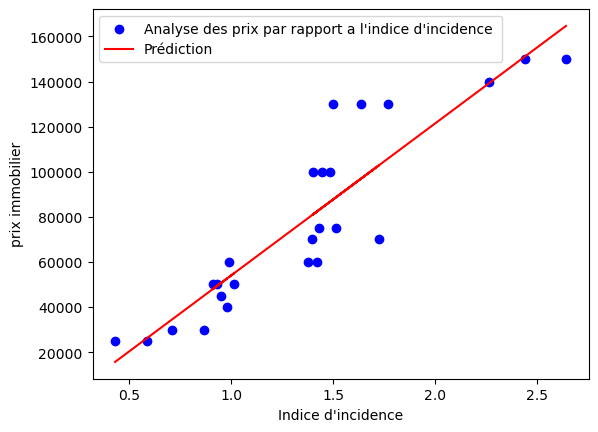

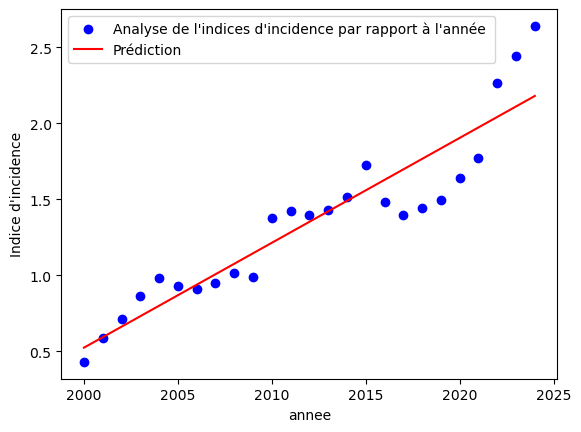

2.594491388785258
En 2030 le prix d'un appartement à 2 chambres sera: 161535.09444890666


In [35]:
import matplotlib.pyplot as plt1
import matplotlib.pyplot as plt2

from sklearn.linear_model import LinearRegression

#X1: variable des II, Y1: variable des prix
X1=np.array(dataPrix[0])
X1 = X1.reshape(-1, 1) #Pour eviter des erreurs sur la dimension du tableau
Y1=np.array(dataPrix[1])

#X2: variable des années, Y2: variable des II
X2=np.array(dataAnnee[1])
X2 = X2.reshape(-1, 1) #Pour eviter des erreurs sur la dimension du tableau
Y2=np.array(dataAnnee[0])

# Création des modèles de régression linéaire
model1 = LinearRegression()
model2 = LinearRegression()

# Entraîner les modèles
model1.fit(X1, Y1)
model2.fit(X2, Y2)

# Prédire les valeurs
Y_pred1 = model1.predict(X1)
Y_pred2 = model2.predict(X2)

# Visualiser les données des prix par rapport à l'indice d'incidence
plt1.scatter(X1, Y1, color='blue', label="Analyse des prix par rapport a l'indice d'incidence ")
plt1.plot(X1, Y_pred1, color='red', label='Prédiction')
plt1.xlabel("Indice d'incidence")
plt1.ylabel('prix immobilier')
plt1.legend()
plt1.show() 

#visualisation des donnée de l'indices d'incidence par rapport à l'année
plt2.scatter(X2, Y2, color='blue', label="Analyse de l'indices d'incidence par rapport à l'année ")
plt2.plot(X2, Y_pred2, color='red', label='Prédiction')
plt2.xlabel("annee")
plt2.ylabel("Indice d'incidence")
plt2.legend()
plt2.show() 

#Calcul du prix pour l'année 2030
annee=2030
ii_annee= (model2.coef_[0])*annee + model2.intercept_ #c'est a dire Y2=aX2+b
prix_annee=(model1.coef_[0])*ii_annee + model1.intercept_  #c'est a dire Y1=aX1+b
print(ii_annee)
print(f"En 2030 le prix d'un appartement à 2 chambres sera: {prix_annee}")

<h2 style="
    color: red;
    text-align:center;
    font-family: cambria math;">
        CONCLUSION
</h2>
<p style=" font-family:cambria math;text-indent:25px"> 
    En somme cette méthode permet de créer un coérhence entre les données rassemblés ce qui permet de creer un lien entre l'environnement du bien immobilier, ses caracteristiques propres et son prix.
</p>